### Multiple Regression: Sales and Marketing Channels

This example task here is to create a predictive model of the impact of advertising spend on sales revenue.
Original dataset source here: https://www.kaggle.com/datasets/sazid28/advertising.csv

Multiple models are evaluate (as i learn i keep adding them).  
Methods inlcude GridSearchCV, Scaling and assumptions evaluation.

Note: most of the models used code generated from Chat GPT. Also some of the code is hacked from other projects.

R-Squared Results as Follows: with Plynomial Regression and Random Forst performed the best, with scores of over 98%, meaning that 98% of the variation in sales was accounatable by advertising spend. 

OLS squared method: adjusted R-Squared: 0.894

Ridge Regression: R-Squared: 0.896

Lasso Regression: R-Squared: 0.90

Polynomial Regression :R-Squared: 0.987

Elastic Net: R-Squared 0.90

Decision Tree: R-Squared: 0.95

Random Forest: R-Squared: 0.98

Gradient Boosting: 0.983

XG Boost: 0.978

Support Vector: 0.87

K-Nearest Neighbor: 0.966

Neural Network MLP: 0.96


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score  # Import the metrics

from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split, GridSearchCV
import statsmodels.api as sm
from scipy.stats import shapiro

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso

from sklearn.linear_model import Ridge

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import cross_val_score

from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Documents\GitHub\Regression Models\Advertising.csv")

In [3]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.drop('Unnamed: 0', axis=1, inplace = True)

In [6]:
df.rename(columns = {'radio': 'Radio', 'newspaper': 'Newspaper', 'sales': 'Sales'}, inplace = True)

Observation: Dataset has 200 records, complete counts across columns. 
TV mean: 147, Radio Mean 23, Newspaper: 30.5, Sales: 14
No null values. All datatypes are floating point.

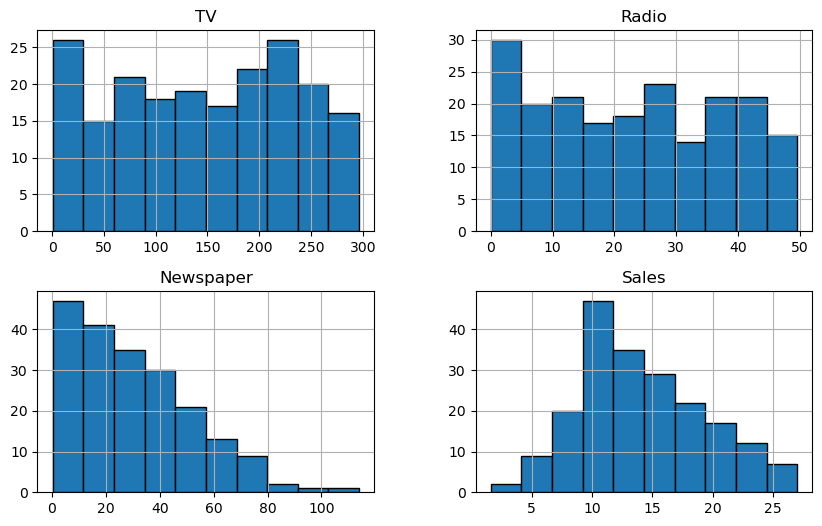

In [7]:
df.hist(figsize=(10,6),bins=10,grid=True,edgecolor='black')
plt.show()

To address the skewness of the "Newspaper" feature, you can try transforming the data to make it more normally distributed. Common transformations include the logarithm, square root, or Box-Cox transformation.

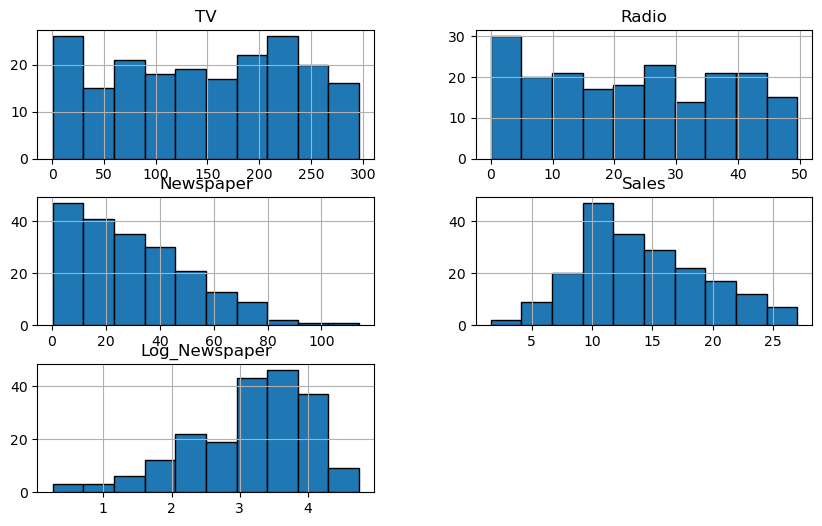

In [8]:
# Apply log transformation (as newspaper is skewed
df['Log_Newspaper'] = np.log1p(df['Newspaper'])
df.hist(figsize=(10,6),bins=10,grid=True,edgecolor='black')
plt.show()

## Outlier Checks

Text(0.5, 1.0, 'Total Sales')

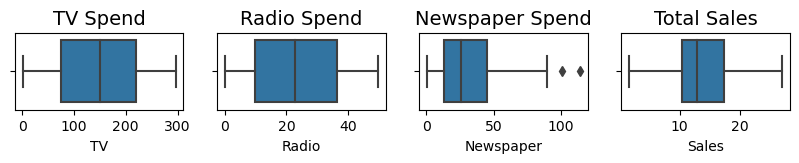

In [9]:
fig, ax = plt.subplots(1, 4, figsize = (10,1))

# Create boxplots
sns.boxplot(data=df, x='TV', orient="h", ax=ax[0])
ax[0].set_title('TV Spend', fontsize='14')

sns.boxplot(data=df, x='Radio', orient="h", ax=ax[1])
ax[1].set_title('Radio Spend', fontsize='14')

sns.boxplot(data=df, x='Newspaper', orient="h", ax=ax[2])
ax[2].set_title('Newspaper Spend', fontsize='14')

sns.boxplot(data=df, x='Sales', orient="h", ax=ax[3])
ax[3].set_title('Total Sales', fontsize='14')

There are a couple of outliers in the Newspaper spend features. We can try removing them to improve model perfromance, but them do not appear signficant.

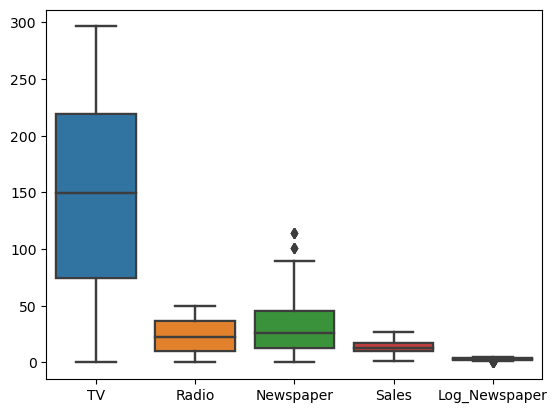

In [10]:
#sns.boxplot(data=df) Same graphs as above, but with quicker simple code.
for i in df.columns:
    sns.boxplot(data=df)

## Outlier adjustment


In [11]:
#Assign outliers in newspaper to the upper limit
percentile25 = df['Newspaper'].quantile(0.25)
percentile75 = df['Newspaper'].quantile(0.75)
iqr = percentile75 - percentile25
lower_limit = percentile25 - 3 * iqr
upper_limit = percentile75 + 3 * iqr

df.loc[df['Newspaper'] > upper_limit, 'Newspaper'] = upper_limit 


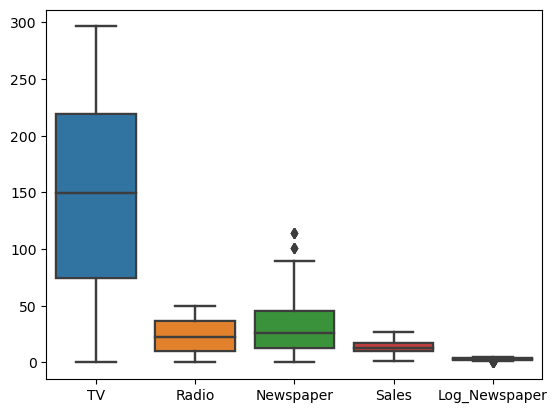

In [12]:
#sns.boxplot(data=df)
for i in df.columns:
    sns.boxplot(data=df)

### NOTE OUTLIERS DO NOT GET REMOVED using the 3 * IQR method, so they will be left in.

## Linearity Assumption Check

Text(0, 0.5, 'Sales ($)')

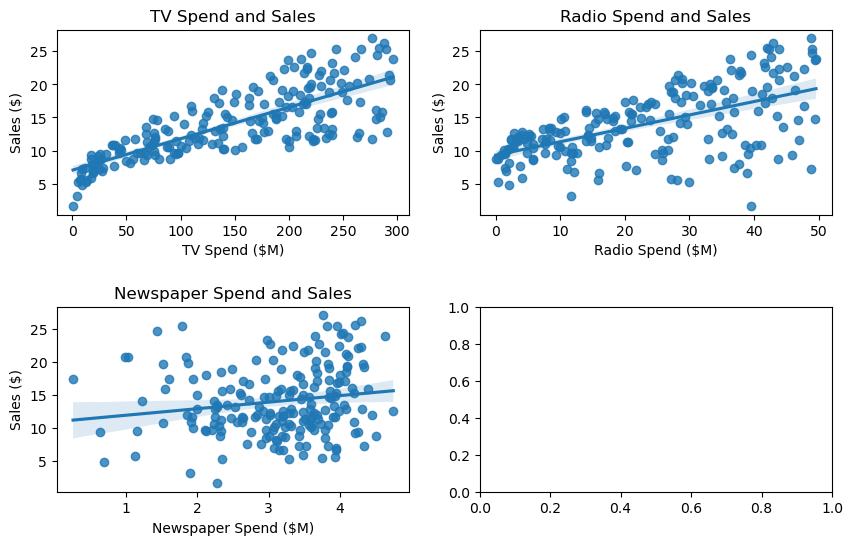

In [13]:
#Outlier Box Plot checks
fig, ax = plt.subplots(2, 2, figsize = (10,6))
#fig.subplots_adjust(h_space=0)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.5)

g = sns.regplot( ax=ax[0,0],
    data = df,
    x = df['TV'],
    y = df['Sales']);
ax[0,0].set_title('TV Spend and Sales')
ax[0,0].set_xlabel('TV Spend ($M)')
ax[0,0].set_ylabel('Sales ($)')


g = sns.regplot( ax=ax[0, 1],
    data = df,
    x = df['Radio'],
    y = df['Sales']);
ax[0,1].set_title('Radio Spend and Sales')
ax[0,1].set_xlabel('Radio Spend ($M)')
ax[0,1].set_ylabel('Sales ($)')

g = sns.regplot( ax=ax[1, 0],
    data = df,
    x = df['Log_Newspaper'],
    y = df['Sales']);
ax[1,0].set_title('Newspaper Spend and Sales')
ax[1,0].set_xlabel('Newspaper Spend ($M)')
ax[1,0].set_ylabel('Sales ($)')

### Linearity displayed between TV, Radio and Sales, very slight between newspaper and Sales

## Correlation
No covariance between Tv, Radio and Newspaper

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


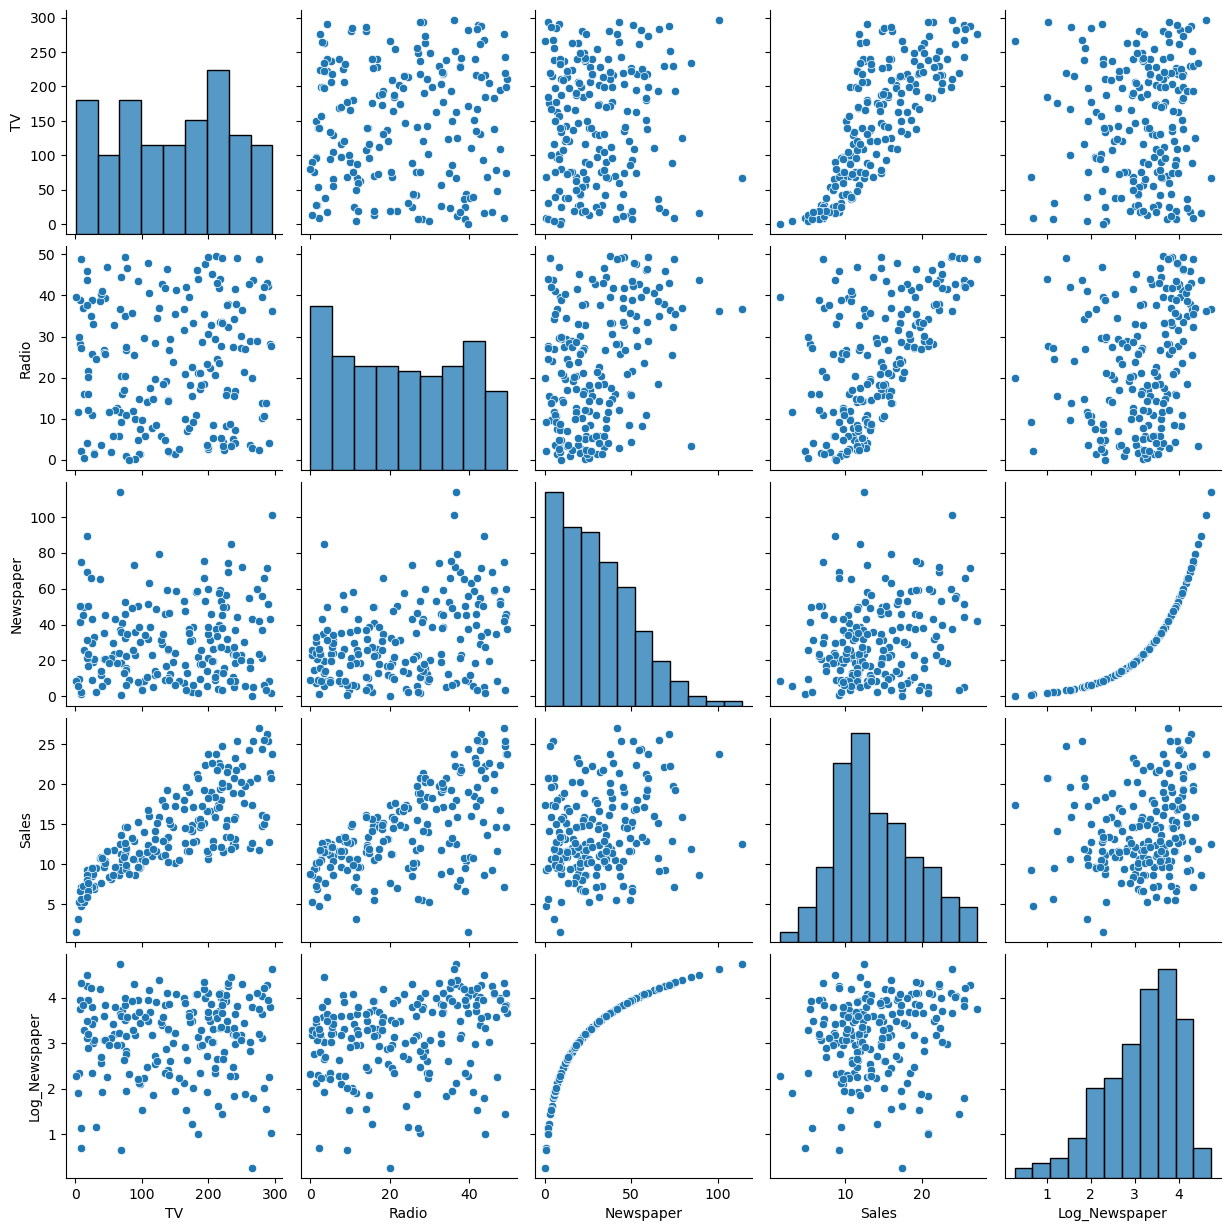

In [14]:
pairplot = sns.pairplot(df) 

<Axes: >

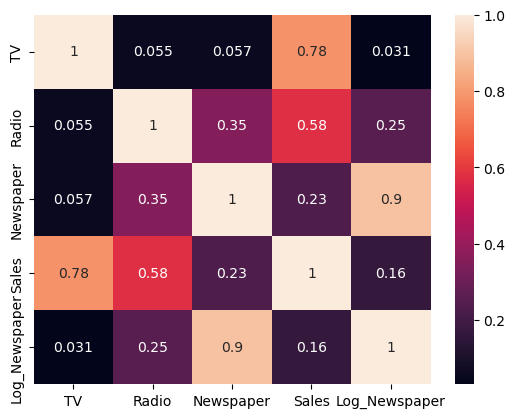

In [15]:
sns.heatmap(data=df.corr(),annot=True)

Strong Correlation between TV and Sales of 0.78% and between  Radio and Sales of 0.58%. 
Correlation between Radio and Newspaper is 0.35, so we should consider removing one of them (Newspaper)

## Preparing the Test and Train data for the model

In [17]:
X = df[['TV', 'Radio', 'Log_Newspaper']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Build the OLS Regression Model and get R-Squared (Adjusted for MLR)

In [18]:
# Write out OLS formula as a string
ols_formula = "Sales ~ TV + Radio + Log_Newspaper"

# Create OLS dataframe
ols_data = pd.concat([X_train, y_train], axis = 1)

# Create OLS object and fit the model
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()

# Get model results
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     447.3
Date:                Wed, 24 Jul 2024   Prob (F-statistic):           2.24e-76
Time:                        14:19:59   Log-Likelihood:                -306.52
No. Observations:                 160   AIC:                             621.0
Df Residuals:                     156   BIC:                             633.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.7314      0.577      4.733      0.000       1.591       3.871
TV                0.0448      0.002     28.556      0.000       0.042       0.048
Radio             0.1890      0.009     20.255      0.000       0.171       0.207
Log_Newspaper     0.1038      0.166      0.627      0.532      -0.223       0.431
==============================================================================
Omnibus:                       66.998   Durbin-Watson:                   2.164
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              233.609
Skew:                          -1.616   Prob(JB):                     1.87e-51
Kurtosis:                       7.959   Cond. No.                         781.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We use the adjusted R-squared as this adjusts for the number of predictors in the model, making it a more accurate measure of model performance when you have multiple predictors. For simple linear regression we can use r squared.

The Adj. R-squared is 0.896. This means that approximately 90% of the total variation in the data can be explained by the model.
This also means that the model doesn’t account for 10% of the data used — this could be due to missing variables, 
for example if there was another marketing channel that wasn’t included, or simply due to noise in the data.

## Run the OLS model against the test data


In [29]:
# Create OLS dataframe for test data
ols_data_test = pd.concat([X_test, y_test], axis=1)

# Predict on the test data
predictions = model.predict(X_test)

# Calculate residuals on the test data
residuals_test = y_test - predictions

# Get the fitted values (predictions) for test data
#fitted_values_test = predictions


## Homeoscedacity 
The variation of the residual (errors) is constant or similar across the model

Homoscedasticity means that the residuals have equal or almost equal variance across the regression line. 

By plotting the error terms with predicted terms we can check that there should not be any pattern in the error terms.



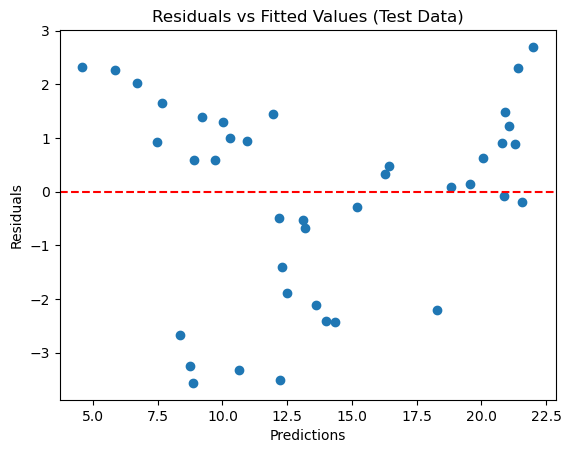

In [30]:
# Plot residuals vs fitted values for test data
plt.scatter(fitted_values_test, residuals_test)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Test Data)')
plt.show()


The variance is relatively equal, so we the homeoscedacity assumptino is met.

## Normality Assumption

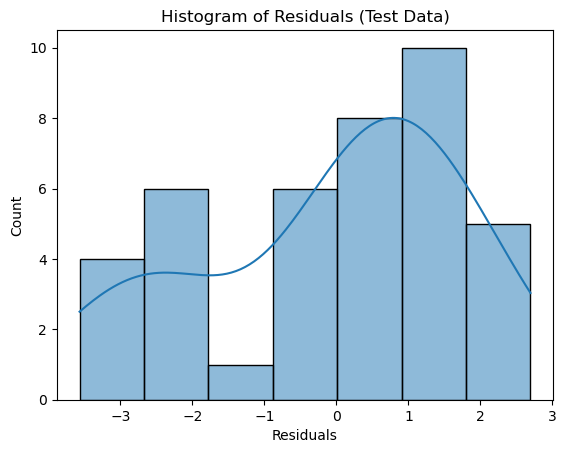

In [31]:
# Plot histogram of residuals for test data
sns.histplot(residuals_test, kde=True)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals (Test Data)')
plt.show()

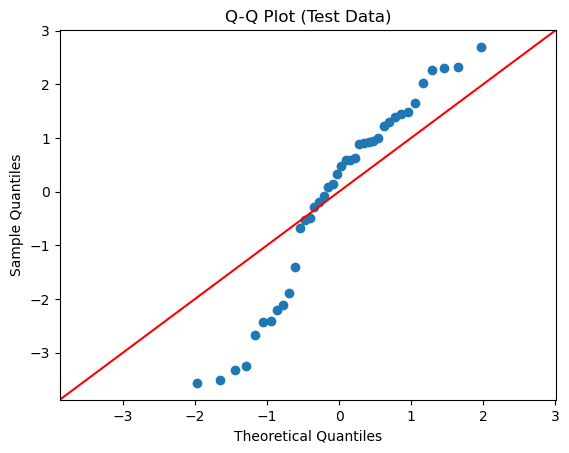

In [32]:
# Q-Q plot for residuals on test data
#Method: Standardize your residuals (convert to z-scores by subtracting the mean and dividing by the standard deviation
#The two axes will be on identical scales, and, if the residuals are indeed normally distributed, the line will be at a 45° angle. 
#The graph  should look normal


sm.qqplot(residuals_test, line='45')
plt.title('Q-Q Plot (Test Data)')
plt.show()

In [23]:
#Test Statistic (W): The test statistic of the Shapiro-Wilk test. Values close to 1 suggest normality.
#p-value: The probability that the observed data would occur by chance if the data was normally distributed.

shapiro_test = shapiro(residuals_test)
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic}, p-value: {shapiro_test.pvalue}')

Shapiro-Wilk test statistic: 0.9300306439399719, p-value: 0.01614294946193695


p-value ≤ 0.05: Reject the null hypothesis. This suggests that the residuals are not normally distributed.

## Ridge Regression

In [36]:
#Ridge Regression (or Tikhonov regularization) adds a penalty term to the linear regression objective function to prevent overfitting. 
#This penalty term is proportional to the square of the magnitude of the coefficients.
#Useful When you have a lot of features or when features are highly collinear.

# Create a Ridge Regression model
ridge_regressor = Ridge(alpha=1.0, random_state=1)

# Train the model
ridge_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = ridge_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 3.1662377893461673
R2 Score: 0.8996870313810141


# Lasso Regression

In [37]:
#Lasso Regression (Least Absolute Shrinkage and Selection Operator) adds a penalty proportional to the absolute value of the coefficients.
#This can lead to some coefficients being exactly zero, which helps in feature selection.
#Useful for Feature selection and regularization in high-dimensional data.

# Create a Lasso Regression model
lasso_regressor = Lasso(alpha=0.1, random_state=1)

# Train the model
lasso_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = lasso_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 3.136340206302692
R2 Score: 0.9006342487124841


# Polynomial Regression

In [38]:
#Polynomial Regression is an extension of linear regression where the relationship between the independent and dependent 
#variables is modeled as an nth degree polynomial.
# Modeling non-linear relationships in the data, such as the growth of a population over time.

# Create polynomial features
poly = PolynomialFeatures(degree=3)  # You can adjust the degree as needed

# Transform the features
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and train the Linear Regression model on polynomial features
poly_regressor = LinearRegression()
poly_regressor.fit(X_train_poly, y_train)

# Predict on the test set
y_pred = poly_regressor.predict(X_test_poly)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.41245238577712673
R2 Score: 0.9869326544675501


# Elastic Net

In [39]:
# Elastic Net combines penalties of both Lasso and Ridge regression. 
#It’s particularly useful when you have many features and some are correlated.
#Situations where you want a balance between Ridge and Lasso regularization.

# Create an ElasticNet model
elastic_net_regressor = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=1)

#alpha is the regularization parameter. It controls the overall strength of the regularization.
#l1_ratio controls the mix between Lasso (L1 regularization) and Ridge (L2 regularization). An l1_ratio of 1.0 is equivalent to Lasso, while an l1_ratio of 0.0 is equivalent to Ridge. An l1_ratio of 0.5 provides a balance between Lasso and Ridge regularization.
#random_state ensures reproducibility of results by setting a seed for the random number generator.

# Train the model
elastic_net_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = elastic_net_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 3.129050618014916
R2 Score: 0.9008651979619743


In [40]:
#Elastic Net with Hyper grid search

parameters = {
    'alpha': [0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.9]
}
grid_search = GridSearchCV(ElasticNet(random_state=1), parameters, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
elastic_net_regressor = grid_search.best_estimator_

# Predict on the test set
y_pred = elastic_net_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Best parameters: {'alpha': 1.0, 'l1_ratio': 0.1}
Mean Squared Error: 3.132425262550647
R2 Score: 0.9007582822361396


# Decision Tree

In [41]:
# Create a decision tree regressor
regressor = DecisionTreeRegressor(random_state=1)

# Train the model
regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 1.5610000000000002
R2 Score: 0.9505442880692253


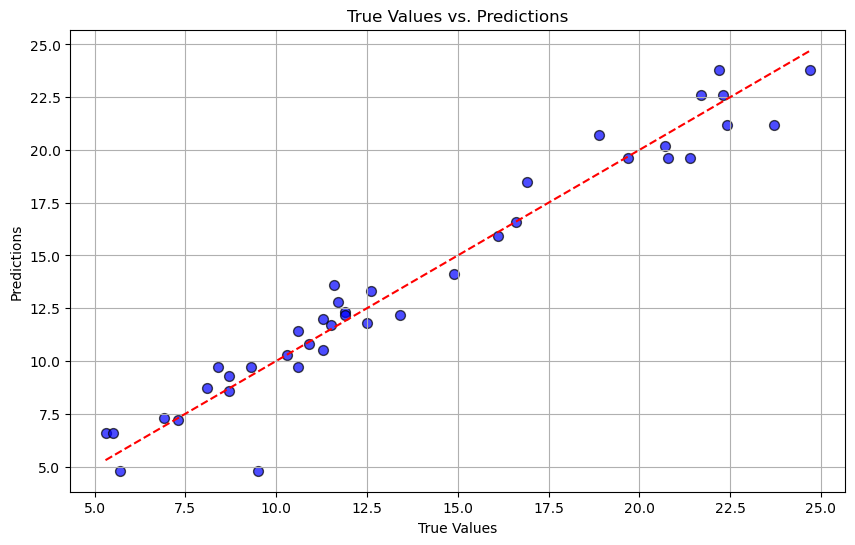

In [43]:
# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs. predicted values
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7, s=50)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True Values vs. Predictions')
# Plot a 45-degree line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.grid(True)
plt.show()

## Random Forest

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define the model
model = RandomForestRegressor(random_state=1)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2', None, 0.5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Define regression-specific scoring metrics
scoring = {
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'r2': 'r2'
}

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring,
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit='r2'  # This tells GridSearchCV to refit the model based on the 'r2' score
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters
best_params = grid_search.best_params_
print(f'Best parameters: {best_params}')

# Get the best model
best_model = grid_search.best_estimator_

# Predict on the test set
pred = best_model.predict(X_test)

# Generate performance metrics
print("Mean Squared Error:", "%.3f" % mean_squared_error(y_test, pred))
print("R2 Score:", "%.3f" % r2_score(y_test, pred))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mean Squared Error: 0.644
R2 Score: 0.980


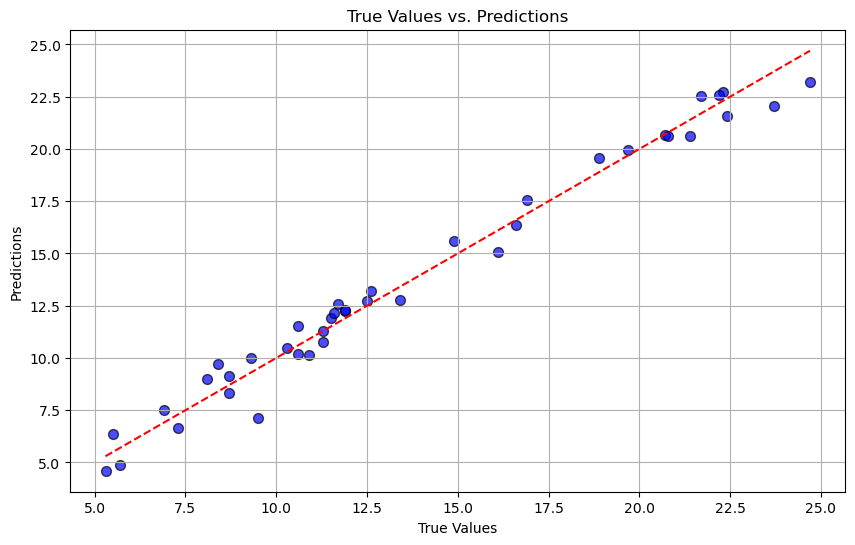

In [45]:
# Plotting
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs. predicted values
plt.scatter(y_test, pred, color='blue', edgecolor='k', alpha=0.7, s=50)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True Values vs. Predictions')
# Plot a 45-degree line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.grid(True)
plt.show()

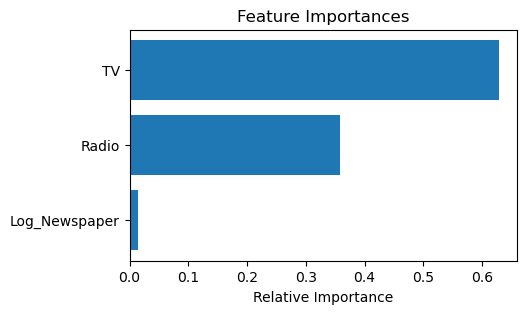

In [47]:
#Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(5, 3))
plt.title('Feature Importances')
plt.barh(range(X_train.shape[1]), importances[indices], align='center')
plt.yticks(range(X_train.shape[1]), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


# Gradient Boosting
Gradient Boosting Regression builds an ensemble of trees sequentially, where each tree corrects the errors of the previous ones. Techniques like XGBoost, LightGBM, and CatBoost are popular implementations.
High performance on structured/tabular data.


In [48]:
# Create a Gradient Boosting Regressor model
gbr_regressor = GradientBoostingRegressor(
    n_estimators=100,  # Number of boosting stages
    learning_rate=0.1,  # Learning rate shrinks the contribution of each tree
    max_depth=3,        # Maximum depth of the individual trees
    random_state=1      # Seed for reproducibility
)

# Train the model
gbr_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = gbr_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.5211870615415024
R2 Score: 0.9834877148125282


## XG Boost


GBoost (Extreme Gradient Boosting) is an optimized implementation of gradient boosting that often delivers high performance in terms of both speed and accuracy. It is widely used in machine learning competitions and real-world applications.

In [49]:
# Create an XGBoost regressor model
xgb_regressor = xgb.XGBRegressor(
    n_estimators=100,       # Number of boosting stages (trees)
    learning_rate=0.1,      # Step size shrinkage
    max_depth=3,            # Maximum depth of the trees
    random_state=1          # Seed for reproducibility
)

# Train the model
xgb_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.679870143529773
R2 Score: 0.9784603062339892


## Support Vector Regression (SVR)

Support Vector Regression is based on the concept of Support Vector Machines and tries to fit the error within a certain threshold.
Situations where the relationship between the features and target variable is not linear.

In [50]:
# Create an SVR model
svr_regressor = SVR(
    kernel='rbf',          # Kernel type: 'linear', 'poly', 'rbf', or 'sigmoid'
    C=1.0,                 # Regularization parameter
    epsilon=0.1            # Epsilon parameter for the margin of tolerance
)

# Train the model
svr_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = svr_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 4.070478670074516
R2 Score: 0.8710388081181498


## K-Nearest Neighbors Regression(KNN)

K-Nearest Neighbors Regression predicts the value of a target variable based on the values of its k-nearest neighbors in the feature space.
When you want a non-parametric method and expect a local relationship between features and target.

In [51]:
# Create a K-Nearest Neighbors Regressor model
knn_regressor = KNeighborsRegressor(
    n_neighbors=5,          # Number of neighbors to use
    weights='uniform',      # Weight function used in prediction ('uniform' or 'distance')
    algorithm='auto'        # Algorithm to compute the nearest neighbors ('auto', 'ball_tree', 'kd_tree', 'brute')
)

# Train the model
knn_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = knn_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 1.0804199999999997
R2 Score: 0.9657700574732558


In [52]:
# Perform cross-validation
cv_scores = cross_val_score(knn_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Calculate and print the mean and standard deviation of cross-validation scores
mean_cv_score = np.mean(-cv_scores)  # Convert from negative MSE to MSE
std_cv_score = np.std(-cv_scores)

print(f"Cross-Validated Mean Squared Error: {mean_cv_score:.3f}")
print(f"Cross-Validated Standard Deviation of MSE: {std_cv_score:.3f}")

Cross-Validated Mean Squared Error: 1.393
Cross-Validated Standard Deviation of MSE: 0.568


The mean MSE across different folds is 1.393. This is slightly higher than the MSE of 1.0804 that you observed on your test set. This difference might indicate that the model is slightly overfitting to your training data, but it’s not a large discrepancy, suggesting the model performs relatively well on unseen data as well.

The standard deviation of MSE is 0.568. This value indicates the variability of the model's performance across different folds. A lower standard deviation suggests more consistent performance across different subsets of the data, while a higher standard deviation indicates greater variability.

In [53]:
# Define a grid of hyperparameters
param_grid = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance']
}

# Create a GridSearchCV object
grid_search = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated MSE:", -grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'n_neighbors': 5, 'weights': 'distance'}
Best cross-validated MSE: 1.0263694565099055


## Multi-Layer Perceptron (MLP) Neural Network

In [54]:
# Create an MLP Regressor model
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100,),  # Number of neurons in the hidden layer
    activation='relu',          # Activation function for hidden layers ('relu', 'tanh', 'logistic')
    solver='adam',              # Solver for weight optimization ('adam', 'lbfgs', 'sgd')
    alpha=0.0001,               # L2 regularization parameter
    max_iter=500,               # Maximum number of iterations for the optimization algorithm
    random_state=1              # Seed for random number generation
)

# Train the model
mlp_regressor.fit(X_train, y_train)

# Predict on the test set
y_pred = mlp_regressor.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 45.25115014897471
R2 Score: -0.4336501257552372


## Scaled the data (Standard Scaling)

In [55]:
#Scaling Method 1
# Scaling
#Standardization: Centers features to have a mean of 0 and a standard deviation of 1.
#note we are only scaling the features here. You can also scale the dependent variable

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#y_train_scaled = scaler.fit_transform(y_train)
#y_test_scaled = scaler.transform(y_test)

In [56]:
#Scaling Method 2
#Normalization, often referred to as min-max scaling, adjusts the feature values to lie within a specific range, usually between 0 and 1. This can be particularly useful when your features have different units or scales

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data based on the fitted scaler
X_test_scaled = scaler.transform(X_test)

### Re-run the MLP Model

In [57]:
# Create an MLP Regressor model
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100,),  # Number of neurons in the hidden layer
    activation='relu',          # Activation function for hidden layers ('relu', 'tanh', 'logistic')
    solver='adam',              # Solver for weight optimization ('adam', 'lbfgs', 'sgd')
    alpha=0.0001,               # L2 regularization parameter
    max_iter=500,               # Maximum number of iterations for the optimization algorithm
    random_state=1              # Seed for random number generation
)


# Train the model
mlp_regressor.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = mlp_regressor.predict(X_test_scaled)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 9.523129601104385
R2 Score: 0.6982875373275774


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Using Grid Search with MLP Model

In [58]:

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=MLPRegressor(max_iter=500, random_state=1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters from the grid search
print("Best parameters:", grid_search.best_params_)

# Predict on the test set using the best model from grid search
y_pred = grid_search.predict(X_test_scaled)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'solver': 'sgd'}
Mean Squared Error: 1.0770281220054727
R2 Score: 0.9658775191907457


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
